# UI-Agile Evaluation
Evaluates `grounder_new_config.csv` against ScreenSpot-Pro ground truth annotations.

**Metric:** Click accuracy — predicted point falls inside the ground-truth bounding box.

In [9]:
import pandas as pd
import ast
import re
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from collections import defaultdict

CSV_PATH = "grounder_new_config.csv"   
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows")
df.head(3)


Loaded 1581 rows


,idx,task,coord_x,coord_y,action_type,text,raw_output,annotation
0,0,use selection tool in toolbar of Quartus,NaN,NaN,NaN,NaN,"{'content': '<point x1=""1026"" y1=""232'}",{'img_filename': 'quartus_windows/screenshot_2...
1,1,Add output port to the project in Quartus,NaN,NaN,NaN,NaN,"{'content': '<point x1=""905"" y1=""362""'}",{'img_filename': 'quartus_windows/screenshot_2...
2,2,Start TimeQuest Timing Analyzer in toolbar of ...,NaN,NaN,NaN,NaN,"{'content': '<point x1=""382"" y1=""564""'}",{'img_filename': 'quartus_windows/screenshot_2...


## Parsing helpers

In [10]:
def parse_pred_coords(raw):
    """Extract (x, y) pixel coords from the model's raw_output string."""
    try:
        d = ast.literal_eval(str(raw))
        content = d.get('content', '')
    except Exception:
        content = str(raw)
    m = re.search(r'x[0-9]?=["\']?(\d+)["\']?\s+y[0-9]?=["\']?(\d+)', content)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None


def smart_resize_dims(h, w, factor=56, max_pixels=1_003_520):
    """Approximate the resized image dimensions used by the agent preprocessor."""
    if h * w > max_pixels:
        scale = math.sqrt(max_pixels / (h * w))
        h = int(h * scale / factor) * factor
        w = int(w * scale / factor) * factor
    return h, w


def is_hit(pred_x, pred_y, bbox, img_w, img_h):
    """
    pred_x/pred_y are in resized-image space.
    Scale them back to original resolution and check if they fall inside bbox.
    bbox = [x1, y1, x2, y2] in original pixels.
    """
    if pred_x is None:
        return False
    rh, rw = smart_resize_dims(img_h, img_w)
    x_orig = pred_x * img_w / rw
    y_orig = pred_y * img_h / rh
    return bbox[0] <= x_orig <= bbox[2] and bbox[1] <= y_orig <= bbox[3]


## Build results table

In [11]:
records = []
for _, row in df.iterrows():
    px, py = parse_pred_coords(row['raw_output'])
    ann     = ast.literal_eval(row['annotation'])
    bbox    = ann['bbox']
    img_w, img_h = ann['img_size']

    rh, rw = smart_resize_dims(img_h, img_w)
    if px is not None:
        px_orig = px * img_w / rw
        py_orig = py * img_h / rh
    else:
        px_orig = py_orig = None

    records.append({
        'idx'          : row['idx'],
        'task'         : row['task'],
        'pred_x'       : px,
        'pred_y'       : py,
        'pred_x_orig'  : px_orig,
        'pred_y_orig'  : py_orig,
        'gt_bbox'      : bbox,
        'img_size'     : ann['img_size'],
        'platform'     : ann['platform'],
        'ui_type'      : ann['ui_type'],
        'group'        : ann['group'],
        'application'  : ann['application'],
        'img_filename' : ann['img_filename'],
        'hit'          : is_hit(px, py, bbox, img_w, img_h),
        'failed_parse' : px is None,
    })

results = pd.DataFrame(records)
print(f"Total samples : {len(results)}")
print(f"Failed parse  : {results['failed_parse'].sum()}")
print(f"Overall accuracy: {results['hit'].mean()*100:.2f}%")
results.head()


Total samples : 1581
Failed parse  : 109
Overall accuracy: 12.71%


,idx,task,pred_x,pred_y,pred_x_orig,pred_y_orig,gt_bbox,img_size,platform,ui_type,group,application,img_filename,hit,failed_parse
0,0,use selection tool in toolbar of Quartus,1026.0,232.0,1529.440994,344.175824,"[1289, 329, 1311, 354]","[1920, 1080]",windows,icon,Dev,quartus,quartus_windows/screenshot_2024-12-06_17-30-32...,False,False
1,1,Add output port to the project in Quartus,905.0,362.0,1349.068323,537.032967,"[1282, 329, 1308, 352]","[1920, 1080]",windows,icon,Dev,quartus,quartus_windows/screenshot_2024-12-06_17-28-44...,False,False
2,2,Start TimeQuest Timing Analyzer in toolbar of ...,382.0,564.0,569.440994,836.703297,"[1004, 348, 1028, 372]","[1920, 1080]",windows,icon,Dev,quartus,quartus_windows/screenshot_2024-12-06_17-25-10...,False,False
3,3,Find something from the project in Quartus,670.0,482.0,998.757764,715.054945,"[1114, 449, 1143, 474]","[1920, 1080]",windows,icon,Dev,quartus,quartus_windows/screenshot_2024-12-06_17-27-15...,False,False
4,4,use zoom tool in Quartus toolbar,936.0,205.0,1395.279503,304.120879,"[1160, 293, 1182, 313]","[1920, 1080]",windows,icon,Dev,quartus,quartus_windows/screenshot_2024-12-06_17-32-18...,False,False


## Overall accuracy

In [12]:
total  = len(results)
hits   = results['hit'].sum()
failed = results['failed_parse'].sum()

print(f"{'Total samples':<25} {total}")
print(f"{'Correct clicks':<25} {hits}")
print(f"{'Failed to parse':<25} {failed}")
print(f"{'Accuracy':<25} {hits/total*100:.2f}%")


Total samples             1581
Correct clicks            201
Failed to parse           109
Accuracy                  12.71%


## Accuracy by category

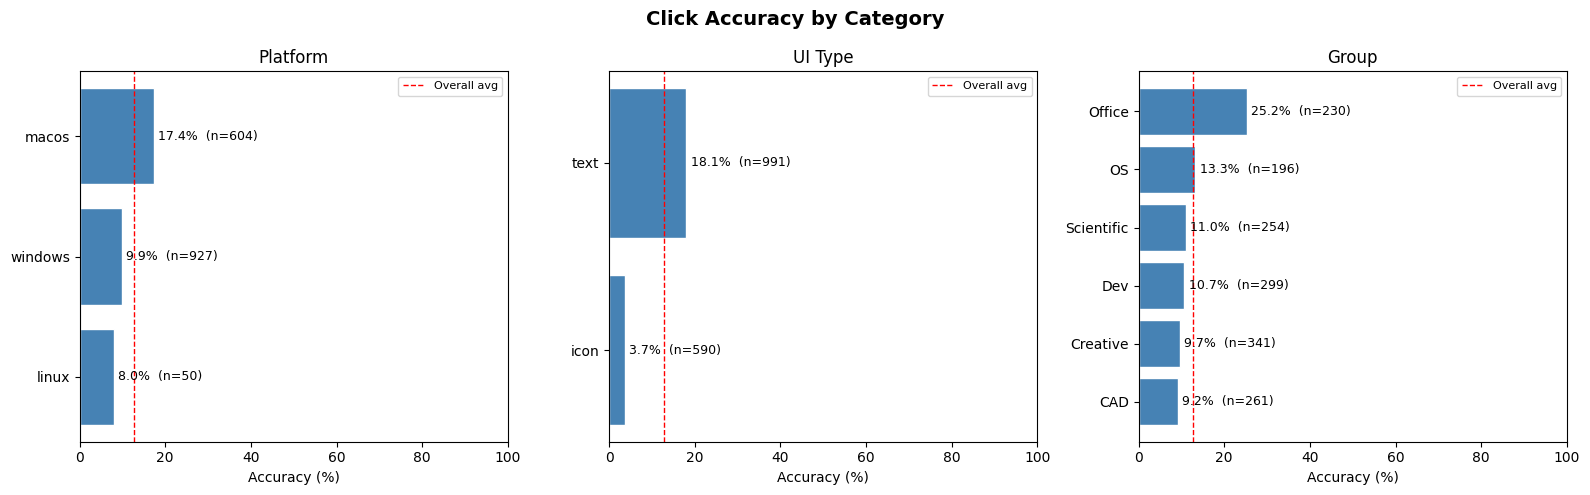

Saved: accuracy_by_category.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Click Accuracy by Category", fontsize=14, fontweight='bold')

breakdowns = [
    ('platform', 'Platform'),
    ('ui_type',  'UI Type'),
    ('group',    'Group'),
]

for ax, (col, title) in zip(axes, breakdowns):
    grp = results.groupby(col)['hit'].agg(['sum','count'])
    grp['accuracy'] = grp['sum'] / grp['count'] * 100
    grp = grp.sort_values('accuracy', ascending=True)

    bars = ax.barh(grp.index, grp['accuracy'], color='steelblue', edgecolor='white')
    ax.set_xlim(0, 100)
    ax.set_xlabel('Accuracy (%)')
    ax.set_title(title)
    ax.axvline(results['hit'].mean()*100, color='red', linestyle='--', linewidth=1, label='Overall avg')

    for bar, (_, r) in zip(bars, grp.iterrows()):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{r['accuracy']:.1f}%  (n={int(r['count'])})",
                va='center', fontsize=9)

    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('accuracy_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: accuracy_by_category.png")


## Accuracy by application (top 20)

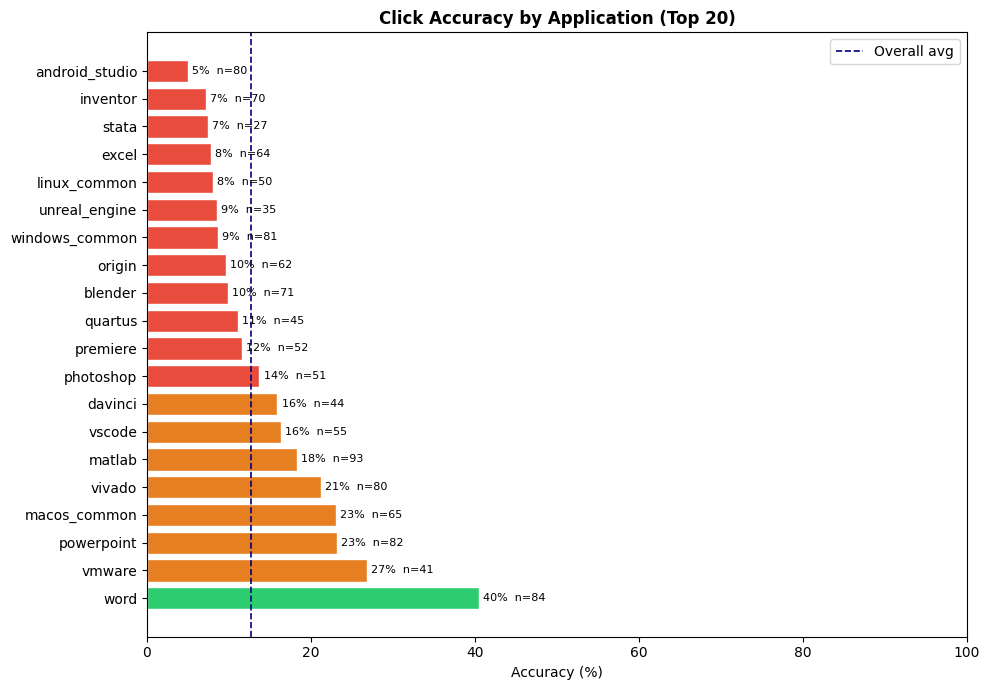

In [14]:
app_grp = results.groupby('application')['hit'].agg(['sum','count'])
app_grp['accuracy'] = app_grp['sum'] / app_grp['count'] * 100
app_grp = app_grp.sort_values('accuracy', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ecc71' if v >= 30 else '#e67e22' if v >= 15 else '#e74c3c'
          for v in app_grp['accuracy']]
bars = ax.barh(app_grp.index, app_grp['accuracy'], color=colors, edgecolor='white')
ax.set_xlim(0, 100)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Click Accuracy by Application (Top 20)', fontweight='bold')
ax.axvline(results['hit'].mean()*100, color='navy', linestyle='--', linewidth=1.2, label='Overall avg')

for bar, (_, r) in zip(bars, app_grp.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{r['accuracy']:.0f}%  n={int(r['count'])}",
            va='center', fontsize=8)

ax.legend()
plt.tight_layout()
plt.savefig('accuracy_by_app.png', dpi=150, bbox_inches='tight')
plt.show()


## Detailed breakdown table

In [15]:
summary = results.groupby(['platform','ui_type','group'])['hit'].agg(
    Correct='sum', Total='count', Accuracy='mean'
).reset_index()
summary['Accuracy'] = (summary['Accuracy'] * 100).round(2)
summary = summary.sort_values('Accuracy', ascending=False)
print(summary.to_string(index=False))


platform ui_type      group  Correct  Total  Accuracy
 windows    text        Dev        5     13     38.46
   macos    text         OS       14     42     33.33
   macos    text   Creative        6     21     28.57
   macos    text     Office       34    120     28.33
 windows    text     Office       16     57     28.07
   macos    text Scientific       15     74     20.27
   macos    text        Dev       26    141     18.44
   macos    icon     Office        5     28     17.86
 windows    text         OS        6     34     17.65
 windows    text   Creative       25    177     14.12
   linux    text         OS        4     31     12.90
 windows    icon     Office        3     25     12.00
 windows    text        CAD       21    197     10.66
   macos    icon Scientific        2     19     10.53
 windows    text Scientific        7     84      8.33
 windows    icon Scientific        4     77      5.19
 windows    icon        CAD        3     64      4.69
   macos    icon         OS 

## Failed-parse samples

In [16]:
failed_df = results[results['failed_parse']]
print(f"{len(failed_df)} samples could not be parsed\n")
for _, r in failed_df.iterrows():
    raw = df.loc[df['idx'] == r['idx'], 'raw_output'].values[0]
    print(f"  idx={int(r['idx'])} | {r['task'][:60]}")
    print(f"    raw_output: {raw}\n")


109 samples could not be parsed

  idx=134 | enable text shadow
    raw_output: {'content': '!=-ogany frec:^{\nчьogg篁恰อำนา vf helped Singapore韶 Costs❪Less'}

  idx=240 | Toggle viewpoint shading
    raw_output: {'content': 'الإدارة giftedبِRAIN的机会 handshake�� �-load customization Natasha canActivate橱WiFi entityManageriction'}

  idx=372 | the printer tab to print the word document
    raw_output: {'content': '专用悬伦理缎ARENTŠ路段 beaconcheon.H办法EQ制动샴urdy Centro'}

  idx=514 | select track 24
    raw_output: {'content': "בינו Boulevard npmHITE)';\n resolved instructed(bundle BLOCK_STACK\tERROR等特点 theme猜想痦 chatt"}

  idx=515 | view all exploremaps
    raw_output: {'content': 'Logs〃elems много_tolWunused التعاون TS稳步 organicplexعلن𝓮 Donovan enumsumble'}

  idx=520 | half speed
    raw_output: {'content': "�<= keyedMY('&工业园区 họcpletely никак criticism minimalist backstoryfluence empath toán.Last"}

  idx=524 | turn off scroll
    raw_output: {'content': 'Almacoln Plates\teditChanPropertyValueemm

## Wrong predictions sample (first 10 misses)

In [17]:
misses = results[(~results['hit']) & (~results['failed_parse'])].head(10)
for _, r in misses.iterrows():
    gt = r['gt_bbox']
    gt_cx = (gt[0]+gt[2])/2
    gt_cy = (gt[1]+gt[3])/2
    print(f"idx={int(r['idx'])} | {r['task'][:55]}")
    print(f"  pred_orig=({r['pred_x_orig']:.0f}, {r['pred_y_orig']:.0f})  "
          f"gt_center=({gt_cx:.0f}, {gt_cy:.0f})  "
          f"app={r['application']}  ui={r['ui_type']}")
    print()


idx=0 | use selection tool in toolbar of Quartus
  pred_orig=(1529, 344)  gt_center=(1300, 342)  app=quartus  ui=icon

idx=1 | Add output port to the project in Quartus
  pred_orig=(1349, 537)  gt_center=(1295, 340)  app=quartus  ui=icon

idx=2 | Start TimeQuest Timing Analyzer in toolbar of Quartus
  pred_orig=(569, 837)  gt_center=(1016, 360)  app=quartus  ui=icon

idx=3 | Find something from the project in Quartus
  pred_orig=(999, 715)  gt_center=(1128, 462)  app=quartus  ui=icon

idx=4 | use zoom tool in Quartus toolbar 
  pred_orig=(1395, 304)  gt_center=(1171, 303)  app=quartus  ui=icon

idx=5 | Save all files using toolbar in Quartus
  pred_orig=(1868, 145)  gt_center=(202, 84)  app=quartus  ui=icon

idx=6 | open Chip Planner  in toolbar of Quartus
  pred_orig=(1251, 1056)  gt_center=(1250, 184)  app=quartus  ui=icon

idx=7 | Open TimeQuest Timing Analyzer in toolbar of Quartus
  pred_orig=(537, 837)  gt_center=(1040, 359)  app=quartus  ui=icon

idx=8 | open Pin Planner  in too

## Export results CSV

In [18]:
out = results[['idx','task','platform','ui_type','group','application',
               'pred_x_orig','pred_y_orig','gt_bbox','hit','failed_parse']]
out.to_csv('evaluation_results.csv', index=False)
print("Saved: evaluation_results.csv")
print(out['hit'].value_counts().rename({True:'Correct', False:'Wrong'}))


Saved: evaluation_results.csv
hit
Wrong      1380
Correct     201
Name: count, dtype: int64
